# Mutual Fund Analytics

## Day 4 – Fund Performance Analytics

### Objective

The objective of this notebook is to evaluate the performance of mutual fund schemes using historical NAV data and benchmark indices.

The notebook computes:

- Daily Returns
- CAGR (1-Year, 3-Year, 5-Year)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

**Author:** Suraj Singh

**Internship:** Bluestock Fintech – Data Analytics Internship

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

## Step 2: Load Datasets

In [3]:
# Load datasets

import pandas as pd

fund_master = pd.read_csv(
    "../data/processed/cleaned_01_fund_master.csv"
)

nav_history = pd.read_csv(
    "../data/processed/cleaned_nav_history.csv"
)

scheme_performance = pd.read_csv(
    "../data/processed/cleaned_scheme_performance.csv"
)

benchmark = pd.read_csv(
    "../data/processed/cleaned_10_benchmark_indices.csv"
)

In [4]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("Scheme Performance:", scheme_performance.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Scheme Performance: (40, 19)
Benchmark: (8050, 3)


In [5]:
print(nav_history.columns)
print(scheme_performance.columns)
print(benchmark.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')
Index(['date', 'index_name', 'close_value'], dtype='str')


# Task 1: Daily Return Analysis

## Objective

The objective of this analysis is to calculate the daily returns for all 40 mutual fund schemes using their historical NAV data. Daily returns help measure day-to-day performance and form the basis for risk metrics such as volatility, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.

In [6]:
# Convert date columns to datetime

nav_history["date"] = pd.to_datetime(nav_history["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

## Step 1.1: Sort NAV History

The NAV data is sorted by AMFI scheme code and date to ensure that returns are calculated in chronological order for each mutual fund.

In [7]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

## Step 1.2: Calculate Daily Returns

Daily return is calculated using the percentage change in NAV between two consecutive trading days.

Formula:

Daily Return = (Today's NAV / Previous Day's NAV) - 1

In [8]:
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"].pct_change()
)

## Step 1.3: Handle Missing Values

The first observation for each mutual fund does not have a previous NAV available, resulting in one missing value per scheme. These records are removed before further analysis.

In [9]:
print(nav_history["daily_return"].isna().sum())

nav_returns = nav_history.dropna(
    subset=["daily_return"]
).copy()

40


## Step 1.4: Summary Statistics

The descriptive statistics provide an overview of the distribution of daily returns, including the mean, standard deviation, minimum, maximum, and quartiles.

In [10]:
nav_returns["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

## Step 1.5: Distribution of Daily Returns

The histogram below visualizes the distribution of daily returns across all mutual fund schemes. A well-behaved distribution centered around zero indicates that the calculated returns are reasonable and suitable for further performance analysis.

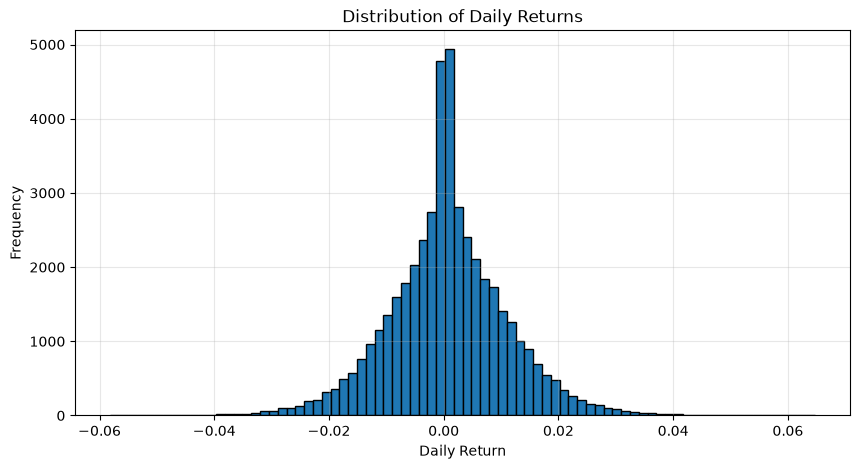

In [12]:
plt.figure(figsize=(10,5))

plt.hist(
    nav_returns["daily_return"],
    bins=80,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

# Save the figure
plt.savefig(
    "../reports/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insight

- Daily returns are concentrated around zero, indicating relatively stable day-to-day NAV movements.
- Most observations fall within a narrow range, while only a few extreme positive and negative returns are observed.
- The calculated daily returns appear reasonable and can be used for subsequent performance metrics such as CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.

# Task 2: Compound Annual Growth Rate (CAGR)

## Objective

Compound Annual Growth Rate (CAGR) measures the average annual growth rate of a mutual fund over a specified period, assuming returns are compounded annually.

This analysis calculates the CAGR for 1-year, 3-year, and 5-year periods for all mutual fund schemes and compares their long-term performance.

In [13]:
# Calculate CAGR for each mutual fund

cagr_results = []

for scheme in nav_history["amfi_code"].unique():

    df = nav_history[
        nav_history["amfi_code"] == scheme
    ].sort_values("date")

    end_date = df["date"].max()
    end_nav = df.iloc[-1]["nav"]

    result = {
        "amfi_code": scheme
    }

    for years in [1, 3, 5]:

        start_date = end_date - pd.DateOffset(years=years)

        temp = df[df["date"] >= start_date]

        if len(temp) > 1:

            start_nav = temp.iloc[0]["nav"]

            cagr = (
                (end_nav / start_nav) ** (1 / years)
            ) - 1

            result[f"CAGR_{years}Y"] = cagr

        else:

            result[f"CAGR_{years}Y"] = None

    cagr_results.append(result)

cagr_df = pd.DataFrame(cagr_results)

## Merge Scheme Information

The calculated CAGR values are merged with the Fund Master dataset to associate each AMFI code with its corresponding scheme name and fund house.

In [14]:
cagr_df = cagr_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,fund_house
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


## CAGR Comparison Table

The table below compares the 1-year, 3-year, and 5-year CAGR for all mutual fund schemes.

In [15]:
cagr_df.sort_values(
    "CAGR_3Y",
    ascending=False
).head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,fund_house
16,119094,0.222611,0.351118,0.244453,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund
34,148567,0.203607,0.340009,0.267993,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
24,120504,0.130643,0.324874,0.202340,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
25,120505,0.296047,0.317775,0.283768,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
19,119551,0.604373,0.304565,0.223849,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
30,120843,0.266571,0.295828,0.267425,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
36,148569,0.397518,0.291789,0.276299,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
39,149324,0.651387,0.270004,0.279174,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund


## Visualizing 3-Year CAGR

The following chart ranks mutual fund schemes based on their 3-year CAGR, providing an easy comparison of long-term fund performance.

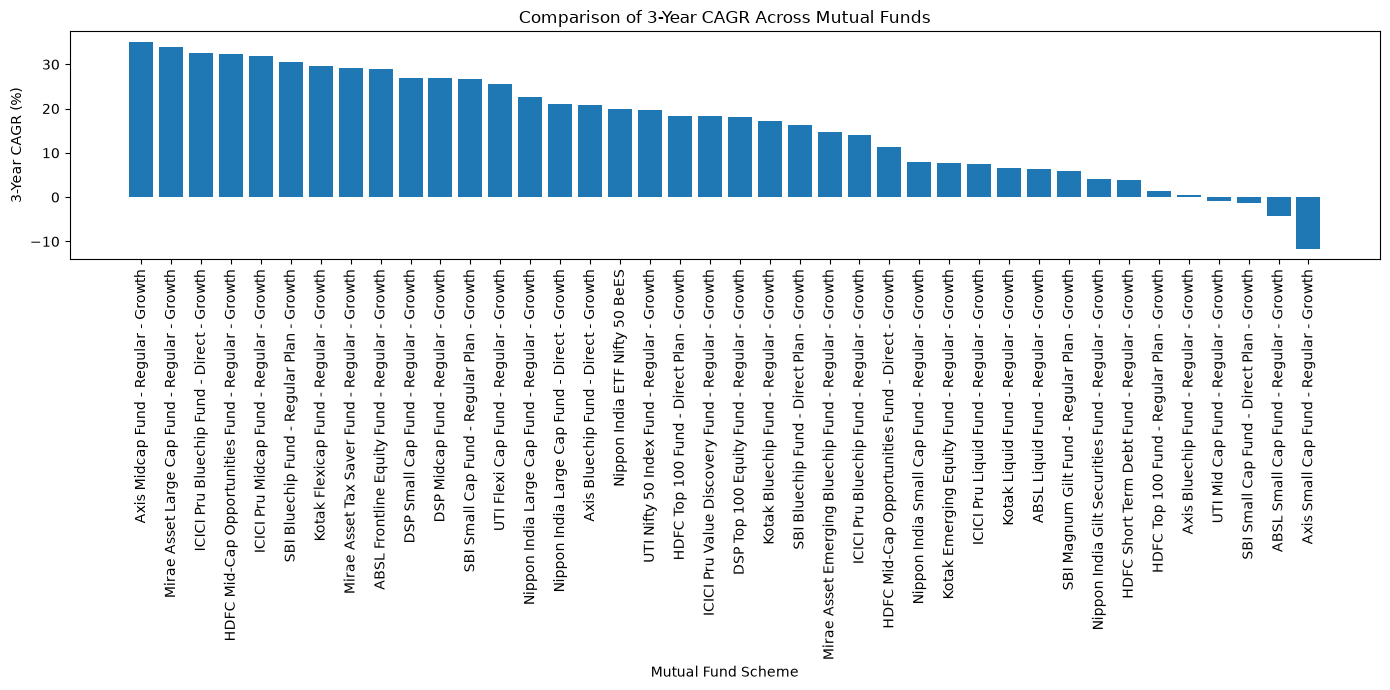

In [16]:
plt.figure(figsize=(14,7))

top = cagr_df.sort_values(
    "CAGR_3Y",
    ascending=False
)

plt.bar(
    top["scheme_name"],
    top["CAGR_3Y"] * 100
)

plt.xticks(rotation=90)

plt.ylabel("3-Year CAGR (%)")
plt.xlabel("Mutual Fund Scheme")
plt.title("Comparison of 3-Year CAGR Across Mutual Funds")

plt.tight_layout()

plt.savefig(
    "../reports/cagr_3year_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insight

- Funds with higher 3-year CAGR have delivered stronger annualized long-term returns.
- CAGR provides a standardized measure for comparing funds with different NAV values.
- The ranking highlights the best-performing schemes over a multi-year investment horizon.

# Task 3: Sharpe Ratio Analysis

## Objective

The Sharpe Ratio measures the risk-adjusted performance of a mutual fund by comparing its excess return over the risk-free rate with its return volatility.

For this analysis, the annual risk-free rate is assumed to be **6.5%**, as specified in the project requirements.

Formula:

Sharpe Ratio = (Rp − Rf) / σ × √252

where:

- Rp = Average Daily Return
- Rf = Daily Risk-Free Rate
- σ = Standard Deviation of Daily Returns
- √252 = Annualization Factor

In [17]:
import numpy as np

## Step 3.1: Define the Risk-Free Rate

The annual risk-free rate is converted to a daily rate for use in the Sharpe Ratio calculation.

In [18]:
# Annual Risk-Free Rate
risk_free_rate = 0.065

# Daily Risk-Free Rate
daily_rf = risk_free_rate / 252

## Step 3.2: Calculate the Sharpe Ratio

The Sharpe Ratio is computed separately for each mutual fund scheme using its daily return series.

In [19]:
sharpe_results = []

for scheme in nav_returns["amfi_code"].unique():

    returns = nav_returns.loc[
        nav_returns["amfi_code"] == scheme,
        "daily_return"
    ]

    mean_return = returns.mean()

    std_return = returns.std()

    sharpe = (
        (mean_return - daily_rf)
        / std_return
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": scheme,
        "Sharpe Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

## Step 3.3: Merge Scheme Details

Merge the calculated Sharpe Ratios with the scheme information to make the results easier to interpret.

In [20]:
sharpe_df = sharpe_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

sharpe_df.head()

,amfi_code,Sharpe Ratio,scheme_name,fund_house
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


## Step 3.4: Rank Mutual Funds by Sharpe Ratio

Higher Sharpe Ratios indicate better risk-adjusted performance.

In [21]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe Ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Sharpe Ratio,scheme_name,fund_house
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
38,149323,1.132122,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF


## Step 3.5: Visualize the Top 10 Funds

The chart below displays the ten mutual fund schemes with the highest Sharpe Ratios.

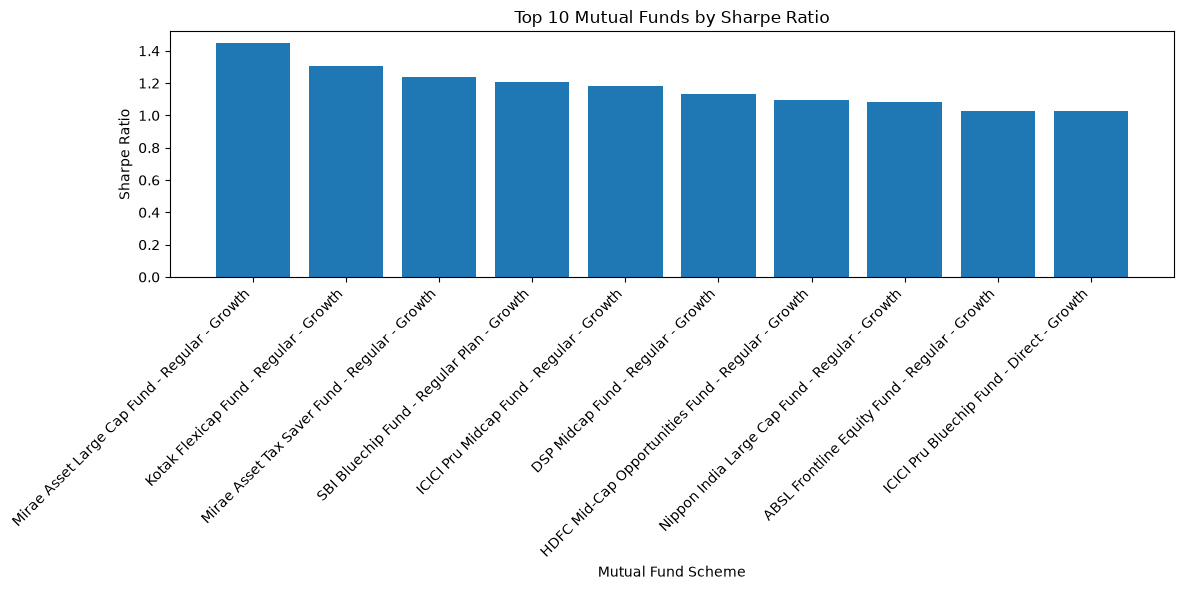

In [22]:
plt.figure(figsize=(12,6))

top10 = sharpe_df.head(10)

plt.bar(
    top10["scheme_name"],
    top10["Sharpe Ratio"]
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Sharpe Ratio")
plt.xlabel("Mutual Fund Scheme")

plt.title("Top 10 Mutual Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/sharpe_ratio_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insight

- Funds with higher Sharpe Ratios generated better returns for each unit of risk taken.
- A higher Sharpe Ratio indicates superior risk-adjusted performance compared to other funds.
- This metric helps identify schemes that consistently balance returns and volatility, making them attractive for long-term investors.

# Task 4: Sortino Ratio Analysis

## Objective

The Sortino Ratio is a risk-adjusted performance metric similar to the Sharpe Ratio. However, instead of considering total volatility, it considers only downside volatility (negative returns).

This provides a better measure of investment performance because investors are generally concerned only with downside risk.

Formula:

Sortino Ratio = (Rp − Rf) / Downside Standard Deviation × √252

## Step 4.1: Calculate Downside Risk

For each mutual fund, only negative daily returns are considered while computing downside standard deviation.

In [23]:
sortino_results = []

for scheme in nav_returns["amfi_code"].unique():

    returns = nav_returns.loc[
        nav_returns["amfi_code"] == scheme,
        "daily_return"
    ]

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    mean_return = returns.mean()

    sortino = (
        (mean_return - daily_rf)
        / downside_std
    ) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": scheme,
        "Sortino Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

## Step 4.2: Merge Scheme Information

The calculated Sortino Ratios are merged with the corresponding mutual fund scheme names and fund houses.

In [24]:
sortino_df = sortino_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

sortino_df.head()

,amfi_code,Sortino Ratio,scheme_name,fund_house
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,0.276644,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


## Step 4.3: Rank Mutual Funds

Higher Sortino Ratios indicate better downside risk-adjusted performance.

In [25]:
sortino_df = sortino_df.sort_values(
    "Sortino Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,Sortino Ratio,scheme_name,fund_house
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
38,149323,1.875101,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF


## Step 4.4: Visualize Top 10 Funds

The following chart ranks the top ten mutual fund schemes based on their Sortino Ratios.

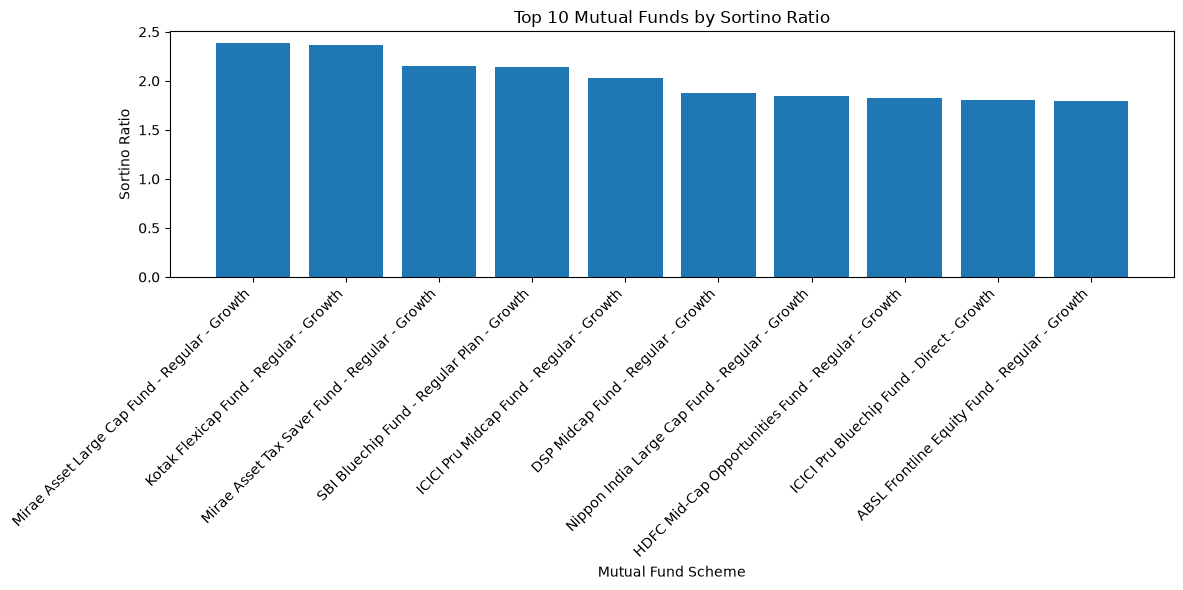

In [26]:
plt.figure(figsize=(12,6))

top10 = sortino_df.head(10)

plt.bar(
    top10["scheme_name"],
    top10["Sortino Ratio"]
)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Mutual Fund Scheme")
plt.ylabel("Sortino Ratio")

plt.title("Top 10 Mutual Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/sortino_ratio_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insight

- The Sortino Ratio focuses exclusively on downside risk, making it particularly useful for evaluating mutual fund performance.
- Funds with higher Sortino Ratios have generated stronger returns while experiencing relatively lower downside volatility.
- Compared to the Sharpe Ratio, the Sortino Ratio provides a more investor-focused assessment of risk-adjusted returns.

# Task 5: Alpha & Beta Analysis

## Objective

Alpha and Beta are widely used performance measures in mutual fund analysis.

- **Beta** measures how sensitive a mutual fund is to market movements.
- **Alpha** measures the fund's excess return after adjusting for market risk.

This analysis estimates Alpha and Beta by performing Ordinary Least Squares (OLS) regression using `scipy.stats.linregress`.

The annualized Alpha is calculated as:

Alpha = Intercept × 252

In [27]:
from scipy.stats import linregress

## Step 5.1: Prepare Benchmark Returns

The benchmark closing prices are converted into daily returns using percentage change.

In [40]:
# Use Nifty 100 benchmark

benchmark_100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

print(benchmark_100.shape)
benchmark_100.head()

benchmark_100 = benchmark_100.sort_values("date")

benchmark_100["benchmark_return"] = (
    benchmark_100["close_value"]
    .pct_change()
)

benchmark_100 = benchmark_100.dropna()

(1150, 3)


## Step 5.2: Calculate Alpha and Beta

Each mutual fund's daily returns are merged with the benchmark returns based on trading dates. Linear regression is then applied to estimate Alpha and Beta.

In [41]:
alpha_beta_results = []

for scheme in nav_returns["amfi_code"].unique():

    fund = nav_returns[
        nav_returns["amfi_code"] == scheme
    ][["date", "daily_return"]]

    merged = fund.merge(
        benchmark_100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({

        "amfi_code": scheme,

        "Alpha": intercept * 252,

        "Beta": slope,

        "R_squared": r_value ** 2

    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

## Step 5.3: Merge Scheme Details

Merge Alpha and Beta values with the corresponding mutual fund names.

In [43]:
alpha_beta_df = alpha_beta_df.merge(

    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house"
        ]
    ],

    on="amfi_code",

    how="left"

)

alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_squared,scheme_name,fund_house
0,100016,0.037476,-0.058268,0.002665,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,0.042818,0.001158,0.000015,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,0.271954,0.005104,0.000012,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,0.213998,0.021086,0.000348,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,0.108971,-0.065289,0.001064,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


## Step 5.4: Top Funds by Alpha

Funds with higher Alpha have generated returns above what would be expected based on their market risk.

In [44]:
alpha_beta_df.sort_values(

    "Alpha",

    ascending=False

).head(10)

,amfi_code,Alpha,Beta,R_squared,scheme_name,fund_house
21,119598,0.303370,-0.023196,1.414258e-04,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
39,149324,0.300579,0.011455,3.532991e-05,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
25,120505,0.292636,0.000549,1.345534e-07,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
36,148569,0.282704,0.018134,1.748889e-04,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
30,120843,0.273305,-0.022830,3.430543e-04,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
2,100033,0.271954,0.005104,1.206652e-05,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
34,148567,0.269838,0.023684,4.625437e-04,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
38,149323,0.265986,-0.002523,3.357978e-06,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
16,119094,0.260767,-0.066265,1.936879e-03,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund
19,119551,0.232010,-0.031751,8.869789e-04,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund


## Step 5.5: Visualize Top Alpha Funds

The following chart ranks the top mutual funds based on annualized Alpha.

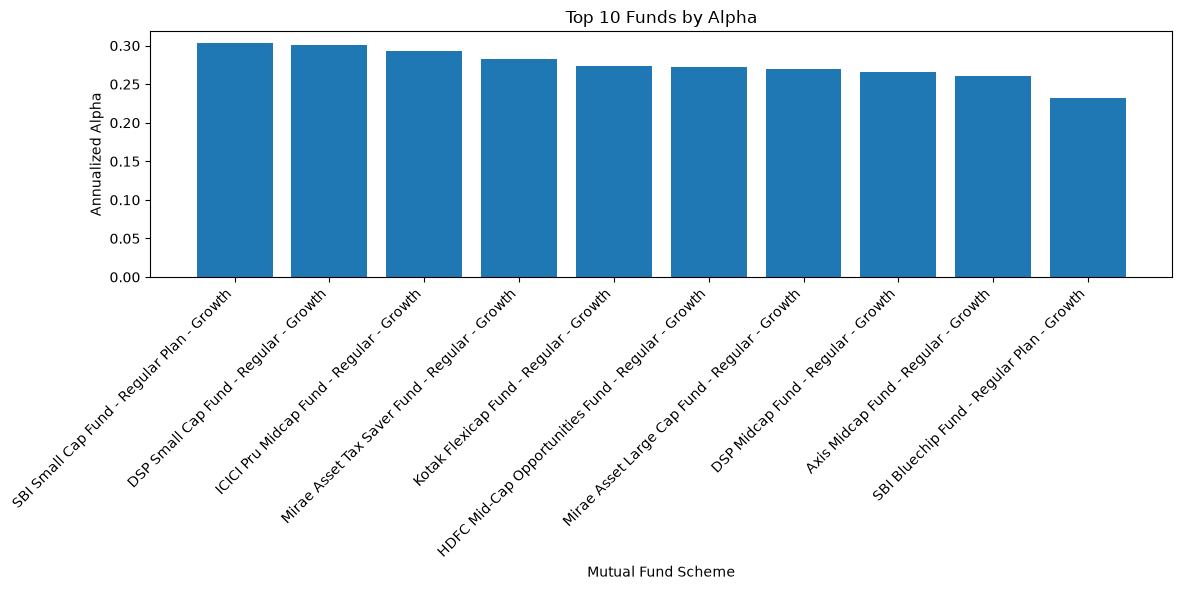

In [45]:
plt.figure(figsize=(12,6))

top = alpha_beta_df.sort_values(

    "Alpha",

    ascending=False

).head(10)

plt.bar(

    top["scheme_name"],

    top["Alpha"]

)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Annualized Alpha")

plt.xlabel("Mutual Fund Scheme")

plt.title("Top 10 Funds by Alpha")

plt.tight_layout()

plt.savefig(

    "../reports/alpha_top10.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

### Key Insight

- Positive Alpha indicates that a mutual fund outperformed the benchmark after accounting for market risk.
- Beta measures the sensitivity of a fund to benchmark movements.
- A Beta close to 1 suggests the fund moves similarly to the market, while values above or below 1 indicate higher or lower volatility relative to the benchmark.

# Task 6: Maximum Drawdown Analysis

In this section, we calculate the Maximum Drawdown (MDD) for each mutual fund scheme. Maximum Drawdown measures the largest decline from a fund's historical peak NAV before recovering. It is an important downside risk metric used to compare the resilience of investment funds.

In [46]:
drawdown_results = []

for code in nav_history["amfi_code"].unique():

    df = nav_history[
        nav_history["amfi_code"] == code
    ].copy()

    df = df.sort_values("date")

    # Running maximum NAV
    df["running_max"] = df["nav"].cummax()

    # Drawdown
    df["drawdown"] = (
        df["nav"] / df["running_max"]
    ) - 1

    # Maximum Drawdown
    max_dd = df["drawdown"].min()

    # Date of worst drawdown
    worst_date = df.loc[
        df["drawdown"].idxmin(),
        "date"
    ]

    drawdown_results.append({
        "amfi_code": code,
        "max_drawdown": max_dd,
        "worst_date": worst_date
    })

In [47]:
drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df = drawdown_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

drawdown_df.head()

,amfi_code,max_drawdown,worst_date,scheme_name,fund_house
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,-0.043083,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,-0.162172,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,-0.112916,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [48]:
drawdown_df = drawdown_df.sort_values(
    "max_drawdown"
)

drawdown_df.head(10)

,amfi_code,max_drawdown,worst_date,scheme_name,fund_house
22,119599,-0.525742,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
17,119095,-0.516778,2026-05-11,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
39,149324,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
21,119598,-0.287060,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
7,102886,-0.280011,2026-04-27,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
29,120842,-0.240035,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF
11,118634,-0.233449,2026-02-20,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF
15,119093,-0.217514,2023-05-22,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund


In [49]:
drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

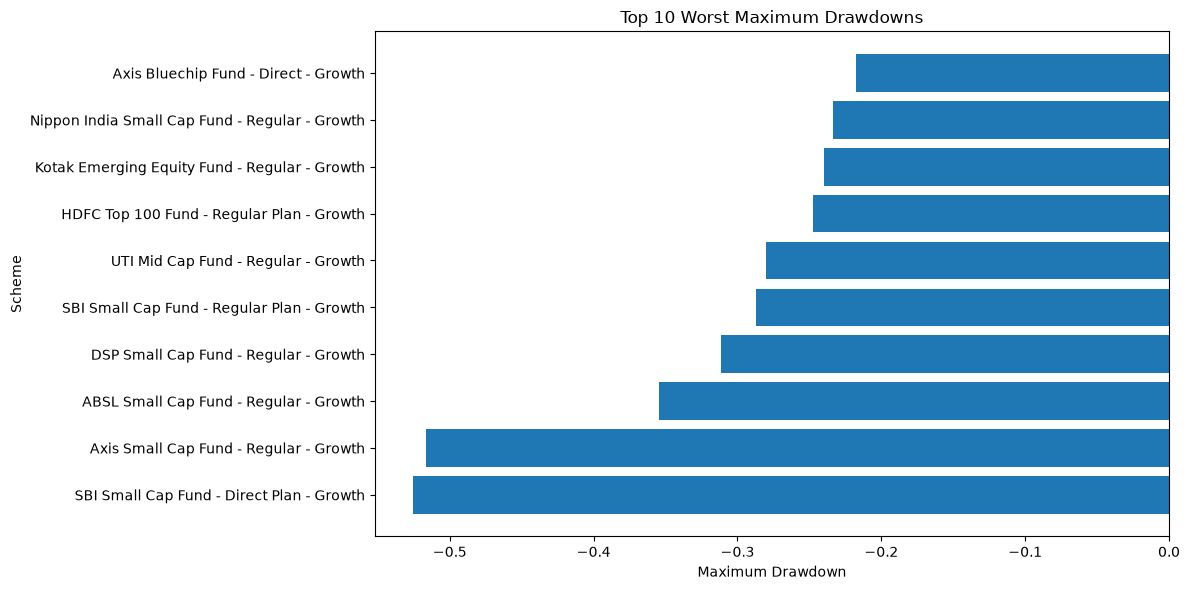

In [50]:
import matplotlib.pyplot as plt

top10 = drawdown_df.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top10["scheme_name"],
    top10["max_drawdown"]
)

plt.xlabel("Maximum Drawdown")
plt.ylabel("Scheme")
plt.title("Top 10 Worst Maximum Drawdowns")

plt.tight_layout()

plt.savefig(
    "../reports/max_drawdown_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

- Maximum Drawdown identifies the largest decline experienced by each fund from its historical peak.
- Funds with smaller drawdowns generally demonstrate better downside protection during market corrections.
- Investors with lower risk tolerance may prefer schemes with relatively smaller maximum drawdowns.

# Task 7: Fund Scorecard

In this section, we create a composite score (0–100) for each mutual fund based on multiple performance and risk metrics. The score combines return, risk-adjusted performance, alpha generation, expense ratio, and downside risk to rank all schemes objectively.

In [61]:
scorecard = scheme_performance[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
].copy()

scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "Sharpe Ratio"]]
    .rename(columns={"Sharpe Ratio": "sharpe_ratio"}),
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]]
    .rename(columns={"Alpha": "alpha"}),
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "max_drawdown"]],
    on="amfi_code"
)

display(scorecard.head())

,amfi_code,scheme_name,fund_house,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,12.36,1.54,1.208267,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,11.30,0.66,0.953279,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,23.39,1.43,0.945308,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,23.14,0.72,-0.057187,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,6.07,0.77,-0.226575,0.056209,-0.043287


In [62]:
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

In [63]:
n = len(scorecard)

scorecard["score"] = (
    30 * (1 - (scorecard["return_rank"] - 1) / (n - 1))
    + 25 * (1 - (scorecard["sharpe_rank"] - 1) / (n - 1))
    + 20 * (1 - (scorecard["alpha_rank"] - 1) / (n - 1))
    + 15 * (1 - (scorecard["expense_rank"] - 1) / (n - 1))
    + 10 * (1 - (scorecard["drawdown_rank"] - 1) / (n - 1))
)

scorecard["score"] = scorecard["score"].round(2)

In [64]:
scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,fund_house,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,18.08,1.36,1.180101,0.292636,-0.181885,8.0,5.0,3.0,15.0,25.0,79.49
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,15.65,1.45,1.306744,0.273305,-0.129740,11.0,2.0,5.0,22.0,13.0,78.46
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,16.58,1.38,1.093699,0.271954,-0.162172,10.0,7.0,6.0,17.0,20.0,75.64
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,21.0,36.0,75.00
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,14.81,1.46,1.448291,0.269838,-0.112657,17.0,1.0,7.0,23.0,8.0,74.36
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,20.08,1.52,0.949796,0.300579,-0.311719,6.0,13.0,2.0,26.5,37.0,68.91
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,17.16,1.61,1.132122,0.265986,-0.172481,9.0,6.0,8.0,38.0,22.0,67.44
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,14.41,0.80,1.026524,0.211948,-0.125883,20.0,10.0,13.0,12.0,12.0,66.41
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,15.18,1.38,0.998231,0.260767,-0.209609,15.0,11.0,9.0,17.0,28.0,65.64
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,13.58,1.60,1.234930,0.282704,-0.163967,23.0,3.0,4.0,36.5,21.0,61.47


In [65]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

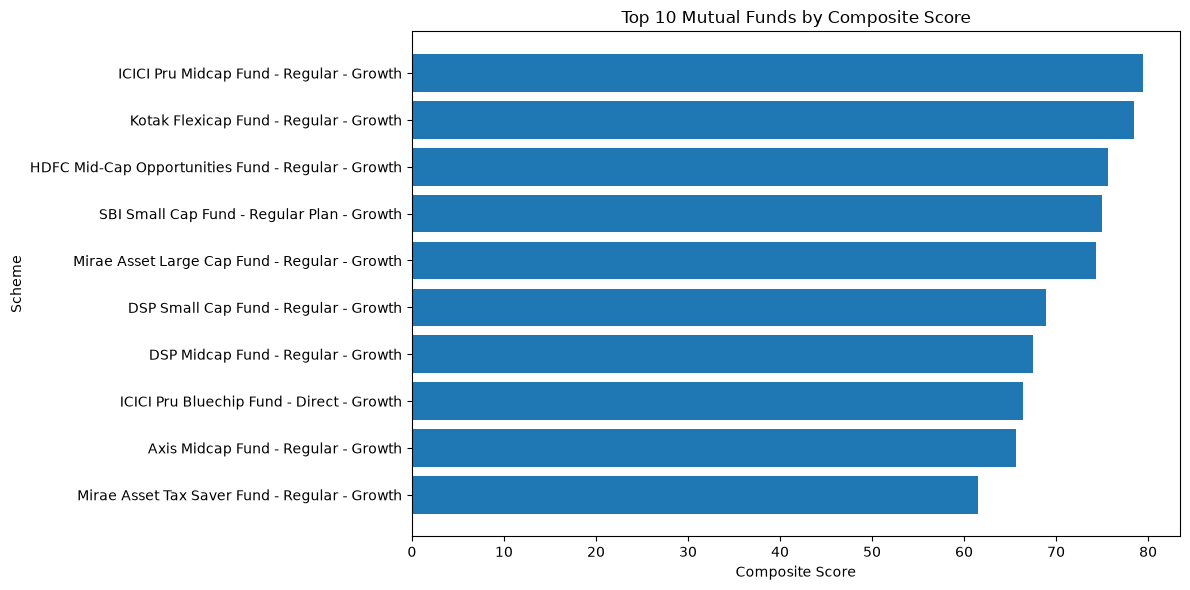

In [66]:
import matplotlib.pyplot as plt

top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["score"]
)

plt.gca().invert_yaxis()

plt.xlabel("Composite Score")
plt.ylabel("Scheme")
plt.title("Top 10 Mutual Funds by Composite Score")

plt.tight_layout()

plt.savefig(
    "../reports/fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

- The composite score provides a balanced evaluation by combining return, risk-adjusted performance, alpha generation, expense ratio, and downside risk.
- Funds with higher scores consistently perform well across multiple dimensions rather than excelling in only one metric.
- This scorecard helps investors compare schemes using a single standardized performance measure.

# Task 8: Benchmark Comparison & Tracking Error

This analysis compares the cumulative NAV performance of the top five mutual funds against the NIFTY 50 and NIFTY 100 benchmark indices over the last three years.

Tracking Error is also calculated to measure how closely each fund follows its benchmark.

In [70]:
top5 = scorecard.head(5)

top5

,amfi_code,scheme_name,fund_house,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,12.36,1.54,1.208267,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,11.30,0.66,0.953279,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,23.39,1.43,0.945308,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,23.14,0.72,-0.057187,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,6.07,0.77,-0.226575,0.056209,-0.043287


In [71]:
# Convert dates
nav_history["date"] = pd.to_datetime(nav_history["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Last 3 years
end_date = nav_history["date"].max()
start_date = end_date - pd.DateOffset(years=3)

# Benchmark data
benchmark_3yr = benchmark[
    benchmark["date"] >= start_date
].copy()

benchmark_3yr.head()

,date,index_name,close_value
365,2023-05-29,NIFTY50,24688.69
366,2023-05-30,NIFTY50,24558.17
367,2023-05-31,NIFTY50,24476.07
368,2023-06-01,NIFTY50,24375.89
369,2023-06-02,NIFTY50,24398.93


In [72]:
top5_codes = top5["amfi_code"].tolist()

top5_nav = nav_history[
    (nav_history["amfi_code"].isin(top5_codes)) &
    (nav_history["date"] >= start_date)
].copy()

top5_nav = top5_nav.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

top5_nav.head()

,amfi_code,date,nav,daily_return,scheme_name
0,119120,2023-05-29,45.7168,-0.000308,SBI Magnum Gilt Fund - Regular Plan - Growth
1,119120,2023-05-30,45.6218,-0.002078,SBI Magnum Gilt Fund - Regular Plan - Growth
2,119120,2023-05-31,45.7637,0.003110,SBI Magnum Gilt Fund - Regular Plan - Growth
3,119120,2023-06-01,45.7428,-0.000457,SBI Magnum Gilt Fund - Regular Plan - Growth
4,119120,2023-06-02,45.9237,0.003955,SBI Magnum Gilt Fund - Regular Plan - Growth


In [73]:
# Normalize fund NAVs
top5_nav["Normalized"] = (
    top5_nav.groupby("scheme_name")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

# Normalize benchmark indices
benchmark_3yr["Normalized"] = (
    benchmark_3yr.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

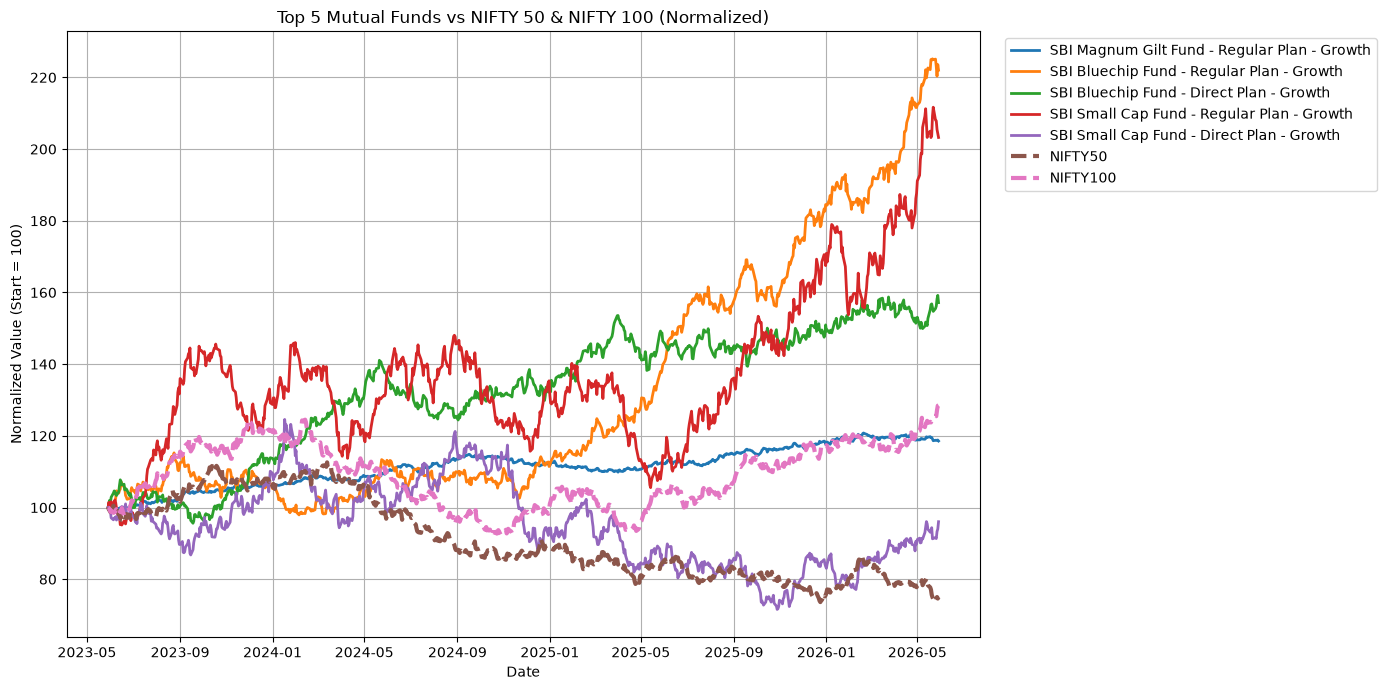

In [74]:
plt.figure(figsize=(14,7))

# Plot Top 5 Funds
for fund in top5_nav["scheme_name"].unique():
    data = top5_nav[top5_nav["scheme_name"] == fund]
    plt.plot(
        data["date"],
        data["Normalized"],
        linewidth=2,
        label=fund
    )

# Plot Benchmarks
for index in ["NIFTY50", "NIFTY100"]:
    data = benchmark_3yr[
        benchmark_3yr["index_name"] == index
    ]

    plt.plot(
        data["date"],
        data["Normalized"],
        linestyle="--",
        linewidth=3,
        label=index
    )

plt.title("Top 5 Mutual Funds vs NIFTY 50 & NIFTY 100 (Normalized)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Start = 100)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The benchmark comparison shows that several of the top-ranked mutual funds outperformed the NIFTY 50 and NIFTY 100 over the three-year period. While benchmark indices exhibited steady growth, the leading funds generated superior cumulative returns, demonstrating effective active fund management.

In [75]:
tracking_error = []

for code in top5_codes:

    fund = top5_nav[
        top5_nav["amfi_code"] == code
    ][["date", "nav"]].copy()

    benchmark_data = benchmark_3yr[
        benchmark_3yr["index_name"] == "NIFTY100"
    ][["date", "close_value"]].copy()

    fund["fund_return"] = fund["nav"].pct_change()

    benchmark_data["benchmark_return"] = (
        benchmark_data["close_value"].pct_change()
    )

    merged = fund.merge(
        benchmark_data,
        on="date"
    ).dropna()

    te = (
        (merged["fund_return"] -
         merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_error.append(
        [
            code,
            te
        ]
    )

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "Tracking Error"
    ]
)

tracking_error_df = tracking_error_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house"
        ]
    ],
    on="amfi_code"
)

tracking_error_df

,amfi_code,Tracking Error,scheme_name,fund_house
0,119551,0.193583,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
1,119552,0.190878,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund
2,119598,0.286689,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
3,119599,0.272098,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
4,119120,0.133312,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund


In [76]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error saved successfully.")

Tracking Error saved successfully.


## Benchmark Comparison & Tracking Error

The cumulative performance of the top five mutual funds was compared with the NIFTY 50 and NIFTY 100 benchmark indices over the previous three years using normalized values.

Tracking Error was calculated as the annualized standard deviation of the difference between fund returns and benchmark returns. Lower tracking error indicates that a fund closely follows its benchmark, while higher values indicate greater deviation from benchmark performance.